# FORMS SDK — Quickstart

A complete mission with the FORMS engine, end to end: build an **Orrery** (FORMS'
N-body manifest), inspect and record variables, author a routine, run the
sequencer, query the Event Engine, and plot the result. Each section is a
template to edit for your own analysis.

## Install / update

Install the SDK into your environment straight from GitHub (the `python/sdk`
subdirectory builds the slim, agent-free `forms-sdk`):

```bash
pip install "git+https://github.com/phi-a/FORMS.git@main#subdirectory=python/sdk"
```

(numpy, pyyaml, and matplotlib come with it — plotting works out of the box.)

**Updating?** Re-run with `--force-reinstall --no-deps` — the version string
rarely changes, so a plain `pip install` sees "already satisfied" and skips the
rebuild.

In [1]:
import os
import sys
import pathlib

nb_dir = pathlib.Path.cwd()
src = nb_dir.parent / "src"                      # dev-clone fallback: import from ./src
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))
res = nb_dir.parent.parent / "resources"         # optional: local EOP / gravity data
if res.exists():
    os.environ.setdefault("FORMS_RESOURCES_DIR", str(res))

import forms
print("forms", forms.__version__)

forms 0.2.0


## 1. Build the Orrery

FORMS' baseline orbit simulation is the **Orrery**: a restricted-N-body
*manifest* — a **center** (the integration origin), ephemeris-read **sources**
that perturb, and integrated **particles**. Two-body is just the degenerate
one-particle manifest; a lone satellite is a one-particle Orrery.

Bootstrap one state from Keplerian elements, then build an Earth-centered Orrery
with Sun + Moon sources and two particles: a `probe` we mark as **the satellite**
(so `forms.satellite`, `orbit`, `lla`, eclipse, and the derive phase all follow
it) and a trailing `debris` companion. `build()` configures the system; stepping
the satellite steps the whole manifest. (A one-off `EOP data not available`
warning is harmless — frames fall back to defaults.)

> Gravity on the Orrery path is point-mass central + third-body sources. For
> oblateness (J2) and drag/SRP on a single satellite, use the degenerate direct
> path — see *Where to go next*.

In [2]:
f = forms.FORMS()

f.load_koe(                                      # bootstrap one state (km, deg)
    a=6928.0, e=0.001, i=51.6,                   # ~550 km altitude, ISS-like inclination
    raan=30.0, aop=40.0, ta=0.0,
    timestamp="2026:01:01:00:00:00",
    mu=f.planet.mu,
)
y0 = f.satellite.get_state()                     # [x, y, z, vx, vy, vz], center-relative
period_s, step_s = float(f.orbit.period), 60.0

f.orrery.set_center("earth").add_source("sun").add_source("moon")
f.orrery.add_particle("probe", y0, satellite=True)   # THE satellite (derive/orbit/lla follow it)
companion = list(y0); companion[1] += 10.0           # a 10 km cross-track neighbour
f.orrery.add_particle("debris", companion)

f.time.set_span(mode="simulated", duration=period_s, units="seconds")
system = f.orrery.build(fixed_dt=step_s)         # configures the system + backs forms.satellite

print(f"orrery: satellite={f.orrery.satellite_name!r} + 1 companion  |  "
      f"period {period_s / 60:.1f} min  ->  {period_s / step_s:.0f} steps of {step_s:.0f} s")

[2026-07-07 14:19:23.228] [FORMS] [WARNING] EOP data not available - transforms will use default values
[2026-07-07 14:19:23.233] [Orrery] [INFO] Orrery: forms.satellite is now backed by particle 'probe' — derive/eclipse/orbit/lla follow it; satellite.step() steps the whole system
orrery: satellite='probe' + 1 companion  |  period 95.6 min  ->  96 steps of 60 s


## 2. Variables & recording

Every mission quantity lives in the **variable registry**. List them, then
**mark** the ones to record — the engine's per-step `record` phase writes each
marked variable to a dated CSV in `outputs/`. The geomagnetic field (`BGCRS`) is
a *derived* variable now: the engine computes it each step, so you just mark it.
We also define our own scalar `sep_km` for the routine in the next cell.

In [3]:
print(f.list_variables())                         # every registered variable

f.set_record_directory("outputs")
for name in ["alt", "sma", "InUmbra", "BGCRS"]:  # derived — the engine fills these each step
    f.get_variable(name).mark()

gap = f.types.scalar("sep_km", 0.0, unit="km")   # define your own variable (the routine fills it)
gap.mark()

['rECI', 'vECI', 'rECEF', 'vECEF', 'lat', 'lon', 'alt', 'sma', 'ecc', 'inc', 'raan', 'aop', 'ta', 'ma', 'gm', 'orbitNumber', 'orbitProgress', 'orbitPhase', 'InUmbra', 'BGCRS', 'BLocal', 'q1', 'q2', 'q3', 'q4', 'omega', 'pointingError', 'satellite_state', 'orrery_state']
[2026-07-07 14:19:26.622] [FORMS] [INFO] Set record directory to outputs


Scalar(name='sep_km', value=0.0)

## 3. Author a routine

The line that splits the library from your code: **a brick is a pure function of
numbers; a routine is a function that takes `forms`.** The engine already derives
`BGCRS`, `alt`, `sma`, … — a routine earns its keep by computing something the
engine does *not* publish. Import the worked routine (`routines/sdk_routine.py`):
the range between our two particles, recorded into `sep_km` every step.

In [4]:
from routines.sdk_routine import track_gap

sample = track_gap(f, "probe", "debris", var="sep_km")   # reads both particle blocks each step

def tick():                                      # bind to the runner's per-step hook
    sample()

## 4. Run the sequence

A **Sequence** is an ordered list of segments run against the handle: `setup`
primes derived state at t0, `propagate` advances it over the span —
`derive -> tick -> step -> record` each step. Because `probe` is the designated
satellite, `step` advances the **whole** Orrery (both particles) through
`forms.satellite.step()`; `record` appends every marked variable to the CSV.
(No `propagator_config.apply()` here — `orrery.build()` already configured the
system.)

In [5]:
from forms.sequence import Sequence, Segment, SequenceRunner, ListSink

sequence = Sequence(name="quickstart", segments=(
    Segment("setup", {}, label="initialize state"),
    Segment("propagate", {}, label="propagate one orbit"),
))
result = SequenceRunner(f, sequence, sink=ListSink(), tick=tick).run()
print(f"{result.name}: {result.steps} steps  ->  {f.recorder.file_path}")

[Recorder] writing to: outputs\FORMS.csv (label=DEFAULT)
[2026-07-07 14:19:35.431] [report] [INFO] Ephemeris written to outputs: ['FORMS.oem']
quickstart: 96 steps  ->  outputs\FORMS.csv


## 5. Inspect the result

One row per step landed in the CSV under `outputs/`. Read it back — the columns
are your marked variables plus the always-on state (`rECIX/Y/Z`, `lat`, `lon`,
`alt`, `sma`, …).

In [6]:
import csv

rows = list(csv.DictReader(open(f.recorder.file_path, newline="")))
print("columns:", ", ".join(rows[0]))
print(f"{len(rows)} rows | alt {float(rows[0]['alt']):.1f} -> {float(rows[-1]['alt']):.1f} km"
      f" | sma {float(rows[-1]['sma']):.1f} km"
      f" | probe-debris gap {float(rows[-1]['sep_km']):.1f} km")

columns: index, timestamp, lat, lon, alt, sma, orbitNumber, orbitProgress, InUmbra, BGCRSX, BGCRSY, BGCRSZ, sep_km
96 rows | alt 548.4 -> 549.0 km | sma 6928.0 km | probe-debris gap 138.5 km


## 6. Eclipse windows

The Event Engine reads the handle's current state — the designated `probe` — and
searches analytically for illumination crossings (a continuous model refined by
bisection), not the sampled telemetry above. Swap `kind` for `penumbra` /
`sunlit`, or pass your own `threshold` / `evaluator` to detect a different
crossing.

In [7]:
summary = f.events.eclipse_summaries_for_orbits(step_s=step_s, kinds=("umbra",))[0]
windows = f.events.eclipse_windows_for_orbits(step_s=step_s, kind="umbra")

print(f"umbra: {summary.window_count} window(s), {summary.total_duration_s:.0f} s, "
      f"{100 * summary.duty_cycle:.1f}% duty")
for w in windows:
    print(f"  {w.start_s:.0f}-{w.stop_s:.0f} s  ({w.duration_s:.0f} s)")

umbra: 1 window(s), 1614 s, 28.1% duty
  2562-4177 s  (1614 s)


## 7. Plot the recorded data

Anything in the CSV plots directly. Here: the derived IGRF-13 field magnitude
(`BGCRS`) and the altitude, over one orbit.

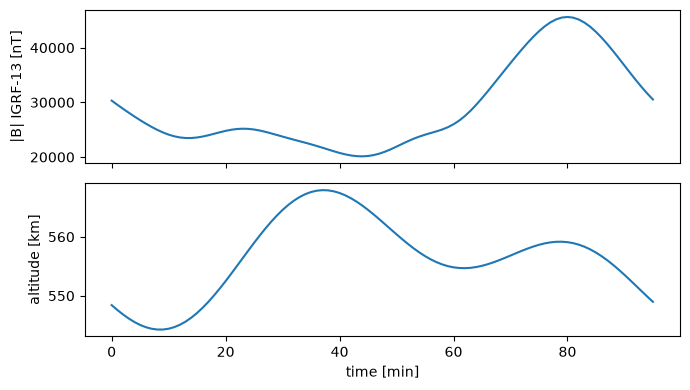

In [8]:
import matplotlib.pyplot as plt

t_min = [i * step_s / 60 for i in range(len(rows))]
B_nT = [(sum(float(r[f"BGCRS{ax}"]) ** 2 for ax in "XYZ")) ** 0.5 * 1e9 for r in rows]
alt = [float(r["alt"]) for r in rows]

fig, (top, bot) = plt.subplots(2, 1, sharex=True, figsize=(7, 4))
top.plot(t_min, B_nT); top.set_ylabel("|B| IGRF-13 [nT]")
bot.plot(t_min, alt); bot.set_ylabel("altitude [km]"); bot.set_xlabel("time [min]")
fig.tight_layout(); plt.show()

## Where to go next

- **A single satellite with J2 / drag / SRP.** The everyday one-satellite path is
  the *degenerate one-particle Orrery* run directly: `f.satellite.force_model.set_gravity("j2")`, `add_third_body("sun")`, `set_drag(...)`, `set_srp(...)`, then `f.satellite.propagator_config.apply()` — the full force registry (J2 included) becomes that particle's dynamics.
- **Formation flying.** Promote a particle with `add_particle(..., mu=...)` so it gravitates its neighbours (mutual N-body).
- **More variables & routines.** Mark any registry variable, or add your own with `f.types.scalar` / `vector` / `boolean`; any `def r(forms): ...` that reads the handle is a routine.
- **Other centers.** Sun- or Mars-centered manifests build today, but *designating* a satellite there is future work — the lla / eclipse / field consumers are still Earth-only.
- **Precise frames.** Run `forms.fetch_resource("eop")` once; the IAU-06 transforms then use real Earth-orientation data instead of defaults.